In [1]:
!pip install pandas numpy networkx python-louvain scikit-learn torch torch-geometric plotly matplotlib

In [2]:
import pandas as pd

df = pd.read_csv("../data/Reviews.csv")
print(df.shape)
df.head()

(568454, 10)


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [3]:
df = df[["UserId", "ProductId", "Score", "Time", "HelpfulnessNumerator", "HelpfulnessDenominator"]]
df = df.dropna()

df_sample = df.sample(n=50000, random_state=42).reset_index(drop=True)
df_sample.head()

,UserId,ProductId,Score,Time,HelpfulnessNumerator,HelpfulnessDenominator
0,A1L01D2BD3RKVO,B000EVG8J2,5,1268179200,0,0
1,A3U62RE5XZDP0G,B0000BXJIS,5,1298937600,0,0
2,AOXC0JQQZGGB6,B008FHUFAU,3,1224028800,0,2
3,A3PWPNZVMNX3PA,B006BXV14E,2,1335312000,0,1
4,A1XNZ7PCE45KK7,B007I7Z3Z0,5,1334707200,0,2


In [4]:
import networkx as nx

G = nx.Graph()

for _, row in df_sample.iterrows():
    user_node = f"user_{row['UserId']}"
    product_node = f"product_{row['ProductId']}"
    G.add_node(user_node, type="user")
    G.add_node(product_node, type="product")
    G.add_edge(user_node, product_node, score=row["Score"], time=row["Time"])

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

Nodes: 61043
Edges: 49929


In [5]:
user_features = []

for user_id, group in df_sample.groupby("UserId"):
    review_count = len(group)
    unique_products = group["ProductId"].nunique()
    avg_score = group["Score"].mean()
    time_span_days = (group["Time"].max() - group["Time"].min()) / 86400  
    helpfulness_ratio = (group["HelpfulnessNumerator"].sum() /
                          max(group["HelpfulnessDenominator"].sum(), 1))

    user_features.append({
        "UserId": user_id,
        "review_count": review_count,
        "unique_products": unique_products,
        "avg_score": avg_score,
        "time_span_days": time_span_days,
        "helpfulness_ratio": helpfulness_ratio,
    })

user_df = pd.DataFrame(user_features)
user_df.head()

,UserId,review_count,unique_products,avg_score,time_span_days,helpfulness_ratio
0,#oc-R11O5J5ZVQE25C,1,1,5.0,0.0,0.0
1,#oc-R149FDXLRARCWJ,1,1,4.0,0.0,0.5
2,#oc-R155JB2SA58E17,1,1,5.0,0.0,0.0
3,#oc-R162D7S0A880MV,1,1,5.0,0.0,0.0
4,#oc-R19EJ3VEA88T6O,1,1,5.0,0.0,0.0


In [6]:
import community as community_louvain

partition = community_louvain.best_partition(G)
user_df["community"] = user_df["UserId"].apply(lambda u: partition.get(f"user_{u}"))

community_stats = user_df.groupby("community").agg(
    size=("UserId", "count"),
    avg_score=("avg_score", "mean")
).reset_index()

community_stats.sort_values("size").head(10)

,community,size,avg_score
15091,15091,1,3.0
11718,11718,1,4.0
4,4,1,4.0
1,1,1,5.0
15088,15088,1,5.0
11717,11717,1,5.0
29,29,1,3.0
15083,15083,1,5.0
15082,15082,1,5.0
15081,15081,1,5.0


In [7]:
suspicious = user_df[
    (user_df["review_count"] >= 5) &
    (user_df["time_span_days"] <= 3) &
    (user_df["avg_score"] >= 4.5) &
    (user_df["helpfulness_ratio"] < 0.3)
]
print(f"Flagged {len(suspicious)} suspicious users out of {len(user_df)}")
suspicious.head(10)

Flagged 7 suspicious users out of 40325


,UserId,review_count,unique_products,avg_score,time_span_days,helpfulness_ratio,community
1484,A152E3J1UPOHPA,5,5,5.0,0.0,0.000000,144
7698,A1Q7BQLP7PBS5B,5,5,5.0,0.0,0.000000,87
9669,A1WZY9GOEE7IAZ,5,5,5.0,0.0,0.000000,45
23871,A38LIPX6GHLI9X,5,5,5.0,0.0,0.000000,45
27130,A3JQ03HF6QI7IV,5,5,5.0,0.0,0.000000,151
31696,A6ZY59M7WOAS0,5,5,5.0,0.0,0.166667,45
33016,ABDCYK04CL6O4,7,7,5.0,0.0,0.000000,517


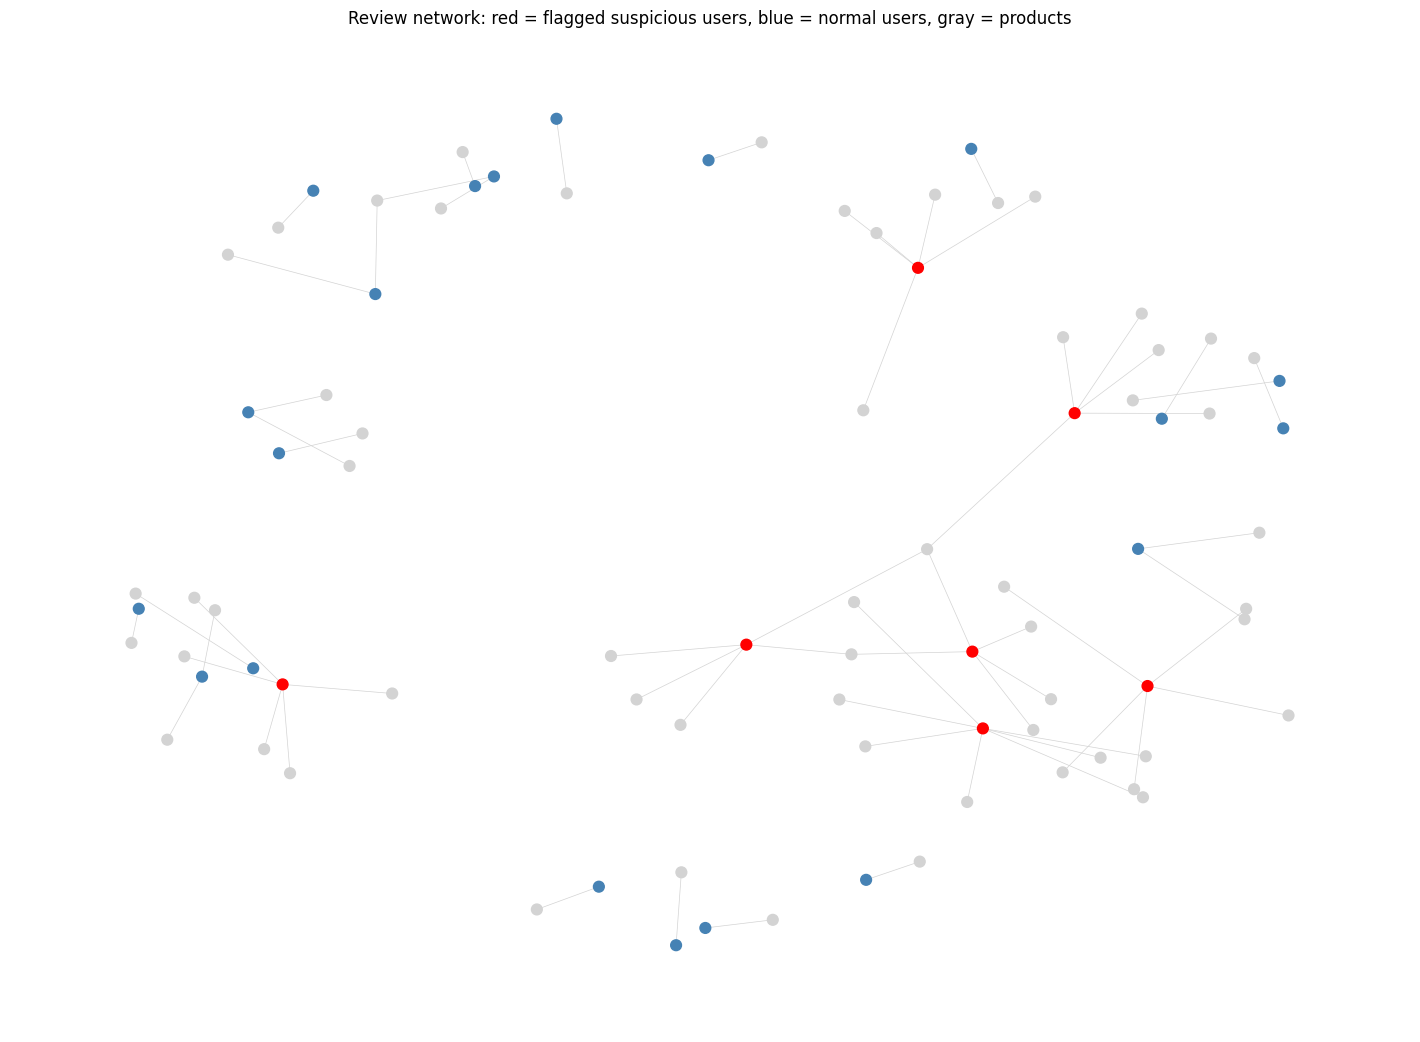

In [8]:
import matplotlib.pyplot as plt

suspicious_ids = set(suspicious["UserId"])
suspicious_nodes = [f"user_{uid}" for uid in suspicious_ids]

nodes_to_show = set()
for node in suspicious_nodes[:15]:  
    if node in G:
        nodes_to_show.add(node)
        nodes_to_show.update(G.neighbors(node)) 

normal_users = [f"user_{uid}" for uid in user_df[~user_df["UserId"].isin(suspicious_ids)]["UserId"].sample(20, random_state=1)]
for node in normal_users:
    if node in G:
        nodes_to_show.add(node)
        nodes_to_show.update(list(G.neighbors(node))[:2])  

subG = G.subgraph(nodes_to_show)

node_colors = []
for node in subG.nodes():
    if node in suspicious_nodes:
        node_colors.append("red")
    elif node.startswith("user_"):
        node_colors.append("steelblue")
    else:
        node_colors.append("lightgray")

plt.figure(figsize=(14, 10))
pos = nx.spring_layout(subG, seed=42, k=0.3)
nx.draw(
    subG, pos,
    node_color=node_colors,
    node_size=60,
    edge_color="lightgray",
    width=0.5,
    with_labels=False
)
plt.title("Review network: red = flagged suspicious users, blue = normal users, gray = products")
plt.savefig(r"C:\Users\adars\OneDrive\Desktop\Graph_Review_Fraud_detection\result\network_visualization.png", dpi=150, bbox_inches="tight")
plt.show()

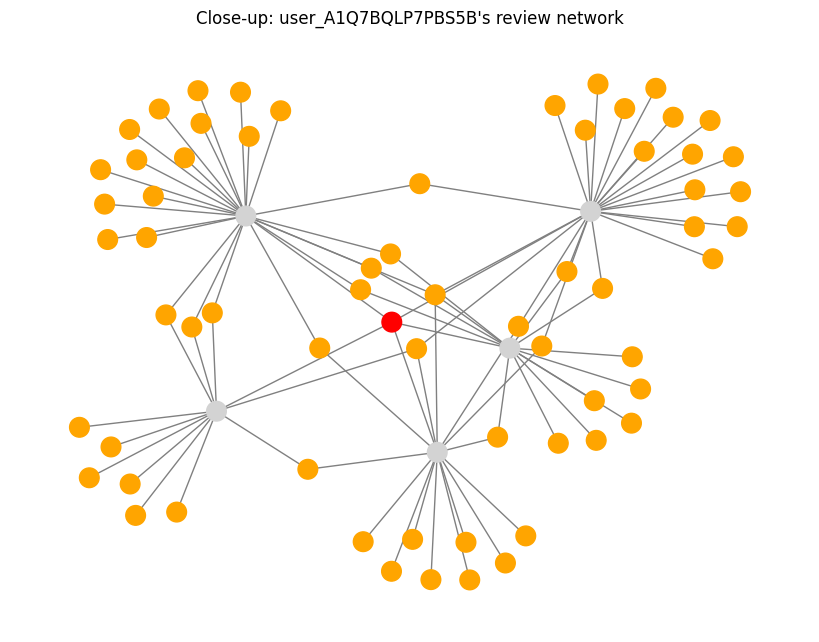


This user reviewed 5 product(s)
Other users who reviewed the SAME product(s) as this user (orange nodes) — 
if several orange nodes cluster tightly around the same gray (product) nodes, that's the overlap pattern that flagged them.


In [9]:
example_user = suspicious_nodes[0]

if example_user in G:
    local_nodes = set([example_user]) | set(G.neighbors(example_user))
    for product in G.neighbors(example_user):
        local_nodes.update(G.neighbors(product))

    local_subG = G.subgraph(local_nodes)
    local_colors = ["red" if n == example_user else
                     "orange" if n.startswith("user_") else
                     "lightgray" for n in local_subG.nodes()]

    plt.figure(figsize=(8, 6))
    pos = nx.spring_layout(local_subG, seed=1)
    nx.draw(local_subG, pos, node_color=local_colors, node_size=200,
            with_labels=False, edge_color="gray")
    plt.title(f"Close-up: {example_user}'s review network")
    plt.savefig(r"C:\Users\adars\OneDrive\Desktop\Graph_Review_Fraud_detection\result\single_case_example.png", dpi=150, bbox_inches="tight")
    plt.show()

    print(f"\nThis user reviewed {len(list(G.neighbors(example_user)))} product(s)")
    print(f"Other users who reviewed the SAME product(s) as this user (orange nodes) — ")
    print("if several orange nodes cluster tightly around the same gray (product) nodes, that's the overlap pattern that flagged them.")

In [10]:
import numpy as np

product_features = []
for product_id, group in df_sample.groupby("ProductId"):
    product_features.append({
        "ProductId": product_id,
        "review_count": len(group),
        "avg_score": group["Score"].mean(),
        "unique_reviewers": group["UserId"].nunique(),
    })
product_df = pd.DataFrame(product_features)

node_list = list(G.nodes())
node_index = {node: i for i, node in enumerate(node_list)}

feature_dim = 4  
X = np.zeros((len(node_list), feature_dim))

user_feat_lookup = user_df.set_index("UserId").to_dict("index")
product_feat_lookup = product_df.set_index("ProductId").to_dict("index")

for node, idx in node_index.items():
    if node.startswith("user_"):
        uid = node.replace("user_", "")
        f = user_feat_lookup.get(uid)
        if f:
            X[idx] = [f["review_count"], f["avg_score"], f["time_span_days"], f["helpfulness_ratio"]]
    else:
        pid = node.replace("product_", "")
        f = product_feat_lookup.get(pid)
        if f:
            X[idx] = [f["review_count"], f["avg_score"], f["unique_reviewers"], 0]

print("Feature matrix shape:", X.shape)

Feature matrix shape: (61043, 4)


In [11]:
import torch
from torch_geometric.data import Data

edge_list = [(node_index[u], node_index[v]) for u, v in G.edges()]
edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()
edge_index = torch.cat([edge_index, edge_index.flip(0)], dim=1)

x = torch.tensor(X, dtype=torch.float)

data = Data(x=x, edge_index=edge_index)
print(data)

C:\Users\adars\AppData\Local\Programs\Python\Python310\lib\site-packages\torch\jit\_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


Data(x=[61043, 4], edge_index=[2, 99858])


In [12]:
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, GAE

class GCNEncoder(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels=32, out_channels=16):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = self.conv2(x, edge_index)
        return x

model = GAE(GCNEncoder(in_channels=X.shape[1]))
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [13]:
model.train()
for epoch in range(1, 101):
    optimizer.zero_grad()
    z = model.encode(data.x, data.edge_index)
    loss = model.recon_loss(z, data.edge_index)
    loss.backward()
    optimizer.step()
    if epoch % 20 == 0:
        print(f"Epoch {epoch}, loss: {loss.item():.4f}")

model.eval()
with torch.no_grad():
    embeddings = model.encode(data.x, data.edge_index).numpy()

print("Embeddings shape:", embeddings.shape)

Epoch 20, loss: 5.2933
Epoch 40, loss: 5.2151
Epoch 60, loss: 3.6325
Epoch 80, loss: 1.5733
Epoch 100, loss: 1.1294
Embeddings shape: (61043, 16)


Total nodes: 61043
Suspicious nodes: 7


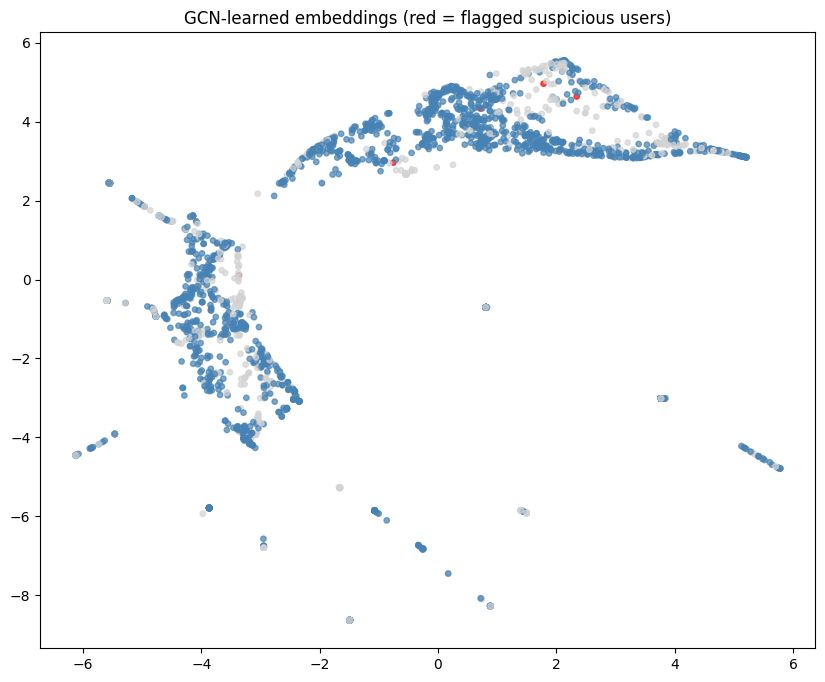

In [14]:
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

suspicious_idx = [i for i, n in enumerate(node_list) if n in suspicious_nodes]
other_idx = [i for i, n in enumerate(node_list) if n not in suspicious_nodes]
sampled_other_idx = np.random.choice(other_idx, size=min(3000, len(other_idx)), replace=False)

viz_idx = suspicious_idx + list(sampled_other_idx)
viz_embeddings = embeddings[viz_idx]
viz_nodes = [node_list[i] for i in viz_idx]
print("Total nodes:", len(node_list))
print("Suspicious nodes:", len(suspicious_idx))

sampled_other_idx = np.random.choice(other_idx, size=min(1000, len(other_idx)), replace=False)  # 1000 instead of 3000

tsne = TSNE(n_components=2, random_state=42, perplexity=15, max_iter=250, init="pca")
emb_2d = tsne.fit_transform(viz_embeddings)

colors = []
for node in viz_nodes:
    if node in suspicious_nodes:
        colors.append("red")
    elif node.startswith("user_"):
        colors.append("steelblue")
    else:
        colors.append("lightgray")

plt.figure(figsize=(10, 8))
plt.scatter(emb_2d[:, 0], emb_2d[:, 1], c=colors, s=15, alpha=0.7)
plt.title("GCN-learned embeddings (red = flagged suspicious users)")
plt.savefig(r"C:\Users\adars\OneDrive\Desktop\Graph_Review_Fraud_detection\result\gcn_embeddings.png", dpi=150, bbox_inches="tight")
plt.show()

In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

user_node_mask = [node.startswith("user_") for node in node_list]
user_embeddings = embeddings[user_node_mask]
user_node_list = [node_list[i] for i in range(len(node_list)) if user_node_mask[i]]

scaler = StandardScaler()
user_embeddings_scaled = scaler.fit_transform(user_embeddings)

iso = IsolationForest(contamination=0.05, random_state=42)
anomaly_pred = iso.fit_predict(user_embeddings_scaled)

gcn_flagged_nodes = [user_node_list[i] for i, pred in enumerate(anomaly_pred) if pred == -1]
print(f"GCN + Isolation Forest flagged {len(gcn_flagged_nodes)} users out of {len(user_node_list)}")

GCN + Isolation Forest flagged 2017 users out of 40325


In [16]:
active_users = user_df[user_df["review_count"] >= 3]["UserId"].tolist()
active_mask = [node.replace("user_", "") in active_users for node in user_node_list]

active_embeddings = user_embeddings_scaled[active_mask]
active_node_list = [user_node_list[i] for i in range(len(user_node_list)) if active_mask[i]]

iso2 = IsolationForest(contamination=0.05, random_state=42)
anomaly_pred2 = iso2.fit_predict(active_embeddings)

gcn_flagged_active = [active_node_list[i] for i, pred in enumerate(anomaly_pred2) if pred == -1]
print(f"Flagged {len(gcn_flagged_active)} out of {len(active_node_list)} ACTIVE users")

Flagged 91 out of 1818 ACTIVE users


In [17]:
sample_check2 = gcn_flagged_active[:10]

for node in sample_check2:
    uid = node.replace("user_", "")
    user_reviews = df_sample[df_sample["UserId"] == uid].sort_values("Time")
    print(f"\n--- {node} ({len(user_reviews)} reviews) ---")
    print(user_reviews[["ProductId", "Score", "Time", "HelpfulnessNumerator", "HelpfulnessDenominator"]])


--- user_A1ZPY91VE3IDN1 (8 reviews) ---
        ProductId  Score        Time  HelpfulnessNumerator  \
12831  B000FFIL92      5  1172620800                     6   
32769  B000UV70M0      5  1229817600                     0   
27670  B001M0A6LA      5  1240272000                     7   
17637  B000FCOOVY      5  1251936000                     3   
130    B001P3PR54      4  1252713600                     5   
30885  B000HDK0D2      5  1291680000                     0   
49270  B002C37TM0      5  1329782400                     3   
11292  B000VZSYCK      4  1332201600                     1   

       HelpfulnessDenominator  
12831                       6  
32769                       0  
27670                       7  
17637                       3  
130                         7  
30885                       0  
49270                       3  
11292                       1  

--- user_A2AOD7254MCKSH (9 reviews) ---
        ProductId  Score        Time  HelpfulnessNumerator  \
30308  B0

In [18]:
rule_based_set = set(suspicious_nodes)
gcn_set = set(gcn_flagged_nodes)

overlap = rule_based_set & gcn_set
only_rule = rule_based_set - gcn_set
only_gcn = gcn_set - rule_based_set

comparison = pd.DataFrame({
    "Method": ["Rule-based baseline", "GCN + Isolation Forest"],
    "Flagged count": [len(rule_based_set), len(gcn_set)],
})
print(comparison)
print(f"\nOverlap between methods: {len(overlap)}")
print(f"Flagged ONLY by rule-based: {len(only_rule)}")
print(f"Flagged ONLY by GCN (new findings): {len(only_gcn)}")

comparison.to_csv(r"C:\Users\adars\OneDrive\Desktop\Graph_Review_Fraud_detection\result\method_comparison.csv", index=False)

                   Method  Flagged count
0     Rule-based baseline              7
1  GCN + Isolation Forest           2017

Overlap between methods: 0
Flagged ONLY by rule-based: 7
Flagged ONLY by GCN (new findings): 2017


In [19]:
gcn_only = set(gcn_flagged_nodes) - set(suspicious_nodes)
sample_check = list(gcn_only)[:10]

for node in sample_check:
    uid = node.replace("user_", "")
    user_reviews = df_sample[df_sample["UserId"] == uid]
    print(f"\n--- {node} ---")
    print(user_reviews[["ProductId", "Score", "Time", "HelpfulnessNumerator", "HelpfulnessDenominator"]])


--- user_AOXMWBNDZDJ9L ---
        ProductId  Score        Time  HelpfulnessNumerator  \
12841  B007JFMH8M      3  1346025600                     0   
15460  B0090X8IPM      2  1290902400                     0   
30135  B008EG5ADY      5  1337904000                     0   

       HelpfulnessDenominator  
12841                       0  
15460                       0  
30135                       0  

--- user_A2JZ8T64YZDQSI ---
        ProductId  Score        Time  HelpfulnessNumerator  \
14024  B000VTTAMY      5  1315180800                     3   
27233  B000CQ01NS      4  1285200000                     0   
32130  B000VTQB6W      5  1315180800                     3   
44599  B003DIIMLK      3  1285200000                     1   

       HelpfulnessDenominator  
14024                       3  
27233                       0  
32130                       3  
44599                       2  

--- user_AWBQTFLTIKYOZ ---
        ProductId  Score        Time  HelpfulnessNumerator  \
5539 

In [20]:
burst_users = []

for node in gcn_flagged_active:
    uid = node.replace("user_", "")
    user_reviews = df_sample[df_sample["UserId"] == uid]
    same_day_counts = user_reviews["Time"].value_counts()
    max_same_day = same_day_counts.max()
    if max_same_day >= 3:
        print(f"{node}: {max_same_day} reviews posted at the exact same timestamp (out of {len(user_reviews)} total)")
        burst_users.append(node)

print(f"\nTotal users with 3+ same-timestamp reviews: {len(burst_users)} out of {len(gcn_flagged_active)} flagged")

user_A3D6OI36USYOU1: 4 reviews posted at the exact same timestamp (out of 14 total)
user_A281NPSIMI1C2R: 3 reviews posted at the exact same timestamp (out of 36 total)
user_A1YUL9PCJR3JTY: 6 reviews posted at the exact same timestamp (out of 45 total)
user_A1LZJZIHUPLDV4: 3 reviews posted at the exact same timestamp (out of 12 total)
user_A2MUGFV2TDQ47K: 5 reviews posted at the exact same timestamp (out of 19 total)
user_A2FRFAQCWZJT3Q: 4 reviews posted at the exact same timestamp (out of 17 total)
user_A21VGNU5959O85: 4 reviews posted at the exact same timestamp (out of 7 total)
user_A29JUMRL1US6YP: 9 reviews posted at the exact same timestamp (out of 18 total)
user_A1X1CEGHTHMBL1: 4 reviews posted at the exact same timestamp (out of 17 total)
user_A1UQBFCERIP7VJ: 6 reviews posted at the exact same timestamp (out of 12 total)
user_A1Z54EM24Y40LL: 4 reviews posted at the exact same timestamp (out of 23 total)
user_A1TMAVN4CEM8U8: 7 reviews posted at the exact same timestamp (out of 20 

In [21]:
print(f"Case study candidates: {burst_users}\n")

example = burst_users[0]
uid = example.replace("user_", "")
case_study = df_sample[df_sample["UserId"] == uid].sort_values("Time")
print(f"--- Case study: {example} ---")
print(case_study[["ProductId", "Score", "Time", "HelpfulnessNumerator", "HelpfulnessDenominator"]])

Case study candidates: ['user_A3D6OI36USYOU1', 'user_A281NPSIMI1C2R', 'user_A1YUL9PCJR3JTY', 'user_A1LZJZIHUPLDV4', 'user_A2MUGFV2TDQ47K', 'user_A2FRFAQCWZJT3Q', 'user_A21VGNU5959O85', 'user_A29JUMRL1US6YP', 'user_A1X1CEGHTHMBL1', 'user_A1UQBFCERIP7VJ', 'user_A1Z54EM24Y40LL', 'user_A1TMAVN4CEM8U8', 'user_ADS5APY1NKTL4', 'user_ACYR6O588USK', 'user_A3TVZM3ZIXG8YW', 'user_A135XHGMBR0OWF', 'user_A14L15JM990MBP']

--- Case study: user_A3D6OI36USYOU1 ---
        ProductId  Score        Time  HelpfulnessNumerator  \
44960  B0000DG5AE      5  1153612800                     1   
46650  B002HNC8VW      5  1297296000                     4   
43892  B001EOMQ94      5  1300665600                     2   
29075  B000KEK6X2      4  1307059200                     0   
43212  B001EO5ZFQ      1  1309392000                     1   
12504  B003L8RKWY      5  1309392000                     0   
44984  B0002Z22GS      4  1309478400                     1   
3678   B001SAY0DO      5  1339632000               

In [22]:
comparison_final = pd.DataFrame({
    "Method": ["Rule-based baseline", "GCN + Isolation Forest (active users only)", "Confirmed burst pattern"],
    "Flagged count": [len(suspicious_nodes), len(gcn_flagged_active), len(burst_users)]
})
comparison_final.to_csv("../results/method_comparison.csv", index=False)
comparison_final

,Method,Flagged count
0,Rule-based baseline,7
1,GCN + Isolation Forest (active users only),91
2,Confirmed burst pattern,17
